In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import importlib 
m = importlib.import_module(".model", "src")
em = importlib.import_module(".em", "src")
from matplotlib import pyplot as plt
import numpy as np
import xgi
import scipy.special as ss

# Generate a synthetic hypergraph

In [3]:
# generate some sample data

eta   = 0.8   # node retention in edges
gamma = 0.1   # poisson number of nodes from graph
beta  = 0.2   # poisson number of novel nodes

timesteps = int(1e3)

H = m.GrowingHypergraph()
H.add_edge((0, 1))
H.add_edge((2, 3))

for _ in range(timesteps):
    H.sample_edge(eta, gamma, beta, True)

In [4]:
# estimator likelihood definitions
# pmfs are used in E-step
# m_step estimators are the parameter estimators for each distribution
# used in m-step, using the matrix chi formed in the E-step

# edge sampling: guaranteed version
def guaranteed_edge_sample_pmf(x, t, eta):
    M = x/t*(eta**(x-1))*((1-eta)**(t-x)) # ?
    M[x == 0] = 0
    return M

def guaranteed_edge_sample_m_step(x, t, chi):
    C = np.tril(chi,-1)
    top = ((x-1)*C).sum()
    bottom = ((t-1)*C).sum()
    return top / bottom

eslg = em.EdgeSampleLikelihood(
    pmf = guaranteed_edge_sample_pmf, 
    m_step = guaranteed_edge_sample_m_step
    )

# addition of novel nodes not previously seen in the hypergraph
def novel_nodes_pmf(k, beta):
     return (beta**k)*np.exp(beta)/(ss.factorial(k))

def novel_nodes_m_step(k, chi):
    return k.mean()

nnl = em.NovelNodesLikelihood(pmf = novel_nodes_pmf, m_step = novel_nodes_m_step)

# addition of nodes from rest of hypergraph
def nodes_from_hypergraph_pmf(k, gamma):
    return (gamma**k)*np.exp(-gamma)/(ss.factorial(k))

def nodes_from_hypergraph_m_step(x, chi):
    return (np.tril(chi, -1)*x).sum(axis = 1).mean()

nhl = em.NodesFromHypergraphLikelihood(pmf = nodes_from_hypergraph_pmf, m_step = nodes_from_hypergraph_m_step)

In [5]:
# now we build a model using the guaranteed version of the sampler 
# because that's how we built the original hypergraph
model = em.EM(eslg, nhl, nnl) 

# time to fit the model
model.fit(H)

/storage/homes/pchodrow/HyperGraph/code/src/em.py:123: RuntimeWarning: divide by zero encountered in log
  return np.ma.masked_invalid(np.log(means)).sum()


Step 0: marginal ll = -5187.75170402741
Step 1: marginal ll = -4976.540153129625
Step 2: marginal ll = -4951.742658490137
Step 3: marginal ll = -4948.631934286944
Step 4: marginal ll = -4948.163293357875
Step 5: marginal ll = -4948.084651510303
Step 6: marginal ll = -4948.070867143611
Step 7: marginal ll = -4948.068395700409
Step 8: marginal ll = -4948.067940599434
Step 9: marginal ll = -4948.06785246993
Step 10: marginal ll = -4948.067833689453
Step 11: marginal ll = -4948.0678290282085
Step 12: marginal ll = -4948.06782764027
Step 13: marginal ll = -4948.06782715743


In [6]:
model.pars

{'eta': 0.7980236912569888,
 'beta': 0.22055888223552894,
 'gamma': 0.12172298449565416}

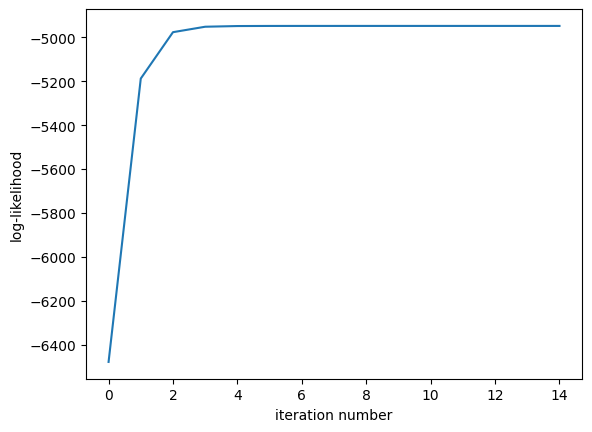

In [7]:
# marginal log-likelihood improves in each iteration
plt.plot(model.ll_history)
labs = plt.gca().set(xlabel = "iteration number", ylabel = "log-likelihood")